## <center>
    <h1 style = "color:blue"> Lab 1-Data Modeling and Fitting </h1>
</center>

(Univariate Linear Regression with SciKitLearn)

By Joshua Brewington

<u>**Introduction**
    
In Lab0 (and the lectures) we introduced ways to fit data with a linear regression. We saw how 
simple linear regression uses a solitary independent variable to predict the outcome of a 
dependent variable. By understanding this, the most basic form of regression, numerous 
complex modeling techniques can be learned. In this lab, we continue to explore linear 
regression but will enhance our techniques by using data that we import from an external 
dataset. We will continue exploring the use Numpy and Pandas. We will also use SciKitLearn’s LinearRegression class and use  its χ2-based method (in other words, a best-fit method). In our 
previous lab, we loaded data from a known source that had noise, and then fitted the noisy 
data with LinearRegression(). In this lab we will use Pandas to again import data that is already 
“noisy”. We will then fit the data to a model function, the simple linear equation, f (x) = ax + b. 

<img src="Images/machine-learning.jpg" width=200; height=200>

<u>Objectives</u>
- Create a professional looking Jupyter Notebook
- Use Pandas and Pandas Dataframes to Import Data
-  Use the SciKitLearn and NumPy modules
-  Perform Linear Regression Analysis with Imported Data
-  Use the MatPlotLib plotting module to plot data
-  Use the Regression Model to Make Predictions

<u>**The Dataset**

    
Source: R.J. Gladstone (1905). "A Study of the Relations of the Brain to to the Size of the Head", 
Biometrika, Vol. 4, pp105-123 
Description: Brain weight (grams) and head size (cubic cm) for 237 adults classified by gender and 
age group. 

Variables/Columns 
- Gender (1=Male, 2=Female) 
- Age Range (1=20-46, 2=46+) 
- Head size (cm^3) 
- Brain weight (grams) 

### Loading the dataset:

In [1]:
import pandas as pd
from pandas.io.parsers import read_csv
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns





#%matplotlib inline
#import matplotlib.pylot as plt
#import numpy as np
#import pandas as pd

**Load the dataset into a pandas dataframe**

In [2]:
df = pd.read_csv('Data/dataset_brain.txt', encoding='utf-8', comment='#',sep='\s+')
df.tail()
# A data file in the format of txt is extracted from a folder titled 'Data'.
# Pandas is reading the txt as csv and then df.tail() is displaying the last 5 rows
#of the dataset.

,gender,age-group,head-size,brain-weight
232,2,2,3214,1110
233,2,2,3394,1215
234,2,2,3233,1104
235,2,2,3352,1170
236,2,2,3391,1120


### Descriptive Statistics:

<img src="Images/std_dev.png" width=400; height=400>

In [3]:
print("The sum of all brain-weight is: ", df['brain-weight'].sum())
print("Mean head-size is: ",df['head-size'].mean())
print("Median head-size is: ",df['head-size'].median())
print("Variance of age-group is: ",df['age-group'].var())
print("Standard Deviation of brain-weight scores is: ",df['brain-weight'].std())
print("Count of people studied are: ",df['brain-weight'].count())
print("Skewness of head-size: ",df['head-size'].skew())
print("Kurtosis of head-size is: ",df['head-size'].kurt())

#This is extracting data from collumns and providing statistical summaries of the dataset.

The sum of all brain-weight is:  304041
Mean head-size is:  3633.9915611814345
Median head-size is:  3614.0
Variance of age-group is:  0.2497675749123927
Standard Deviation of brain-weight scores is:  120.34044578645724
Count of people studied are:  237
Skewness of head-size:  0.2388065848891712
Kurtosis of head-size is:  -0.1134564707717618


## Statistical Correlation:

In [4]:
#df.corr is creating a visual matrix using a heatmap.
dfcorr=df.corr()

In [5]:
df.corr()
#This is showing the statistical correlation between collumns.
#This was done to find "significant" correlation to train the predictive model on.

,gender,age-group,head-size,brain-weight
gender,1.000000,-0.088652,-0.514050,-0.465266
age-group,-0.088652,1.000000,-0.105428,-0.169438
head-size,-0.514050,-0.105428,1.000000,0.799570
brain-weight,-0.465266,-0.169438,0.799570,1.000000


## Visualizing the dataset using a heatmap

<AxesSubplot:>

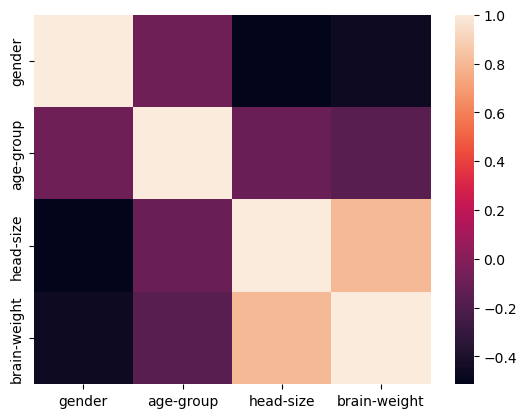

In [6]:
sns.heatmap(dfcorr)

## Plotting the data:

<function matplotlib.pyplot.show(close=None, block=None)>

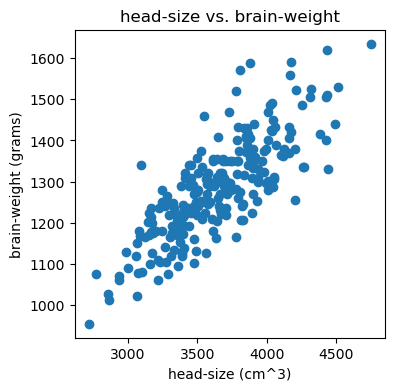

In [7]:
fig=plt.figure(figsize=(4,4))
#plot data and show the plot
plt.xlabel('head-size (cm^3)')
plt.ylabel('brain-weight (grams)')
plt.title("head-size vs. brain-weight")
plt.scatter(df['head-size'], df['brain-weight'])
plt.show

## Preparing the dataset

In [8]:
y = df['brain-weight'].values
y.shape
# The collumn 'brain-weight' is being extracted and reshaped into a 2D numpy array.
# 'y.shape' is displaying what it looks like (rows, collums)

(237,)

In [9]:
X=df['head-size'].values
X=X.reshape(237, 1)
X.shape
# The same thing is being done to X for 'head-size' but adding a collumn with (237, '1')

(237, 1)

In [10]:
print(type(X))
# Here the data structure is displayed.

<class 'numpy.ndarray'>


## Reshape the Matrix

In [11]:
print('Shape',df.shape)
print('Length')

Shape (237, 4)
Length


In [12]:
y = df['brain-weight'].values
y.shape

(237,)

In [13]:
X=df['head-size'].values
X=X.reshape(237, 1)
X.shape

(237, 1)

In [14]:
print(type(X))

<class 'numpy.ndarray'>


## Train/Test Split of dataset

<img src="Images/train_test_split_image.PNG" width=400; height=400>

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=100)

# The dataset is split into two different sets for training and testing.
# The training set trains the model.
# The testing set evaluated the performance.

In [16]:
X_train.shape

(177, 1)

## Fit the Model with Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
linear= LinearRegression()
linear.fit(X_train, y_train)

# This is implementing the training subset into a linear regression model.

LinearRegression()

Text(0.5, 1.0, 'Training dataset vs. Test dataset')

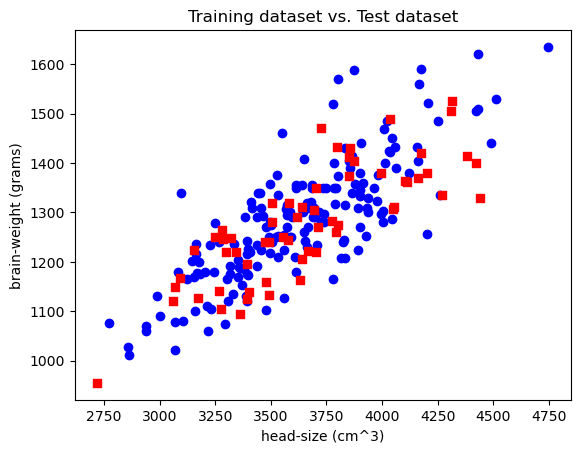

In [18]:
plt.scatter(X_train, y_train, c='blue', marker = 'o')
plt.scatter(X_test, y_test, c='red', marker='s')
plt.xlabel('head-size (cm^3)')
plt.ylabel('brain-weight (grams)')
plt.title('Training dataset vs. Test dataset')

# This is fitting the training and testing datasets into a plot and labeling them different colors.

## Evaluate the Model

In [19]:
slope = linear.coef_
slope[0]

# The slope is derived from the model

0.2746596948750846

In [20]:
intercept= linear.intercept_
intercept

# The intercept is derived from the model

289.2821710467691

From this output, we have determined that the intercept is 289.282 and the regresssion coefficient for the final vs. post-test is 0.274. Therefore, the complete regression equation is:

> ### y_fit=lr.coef_*X + linear.intercept_

> ### with y_fit=brain-weight, X = head-size

> ### brain-weight =(0.274)*head-size + 289.282

## Predict the brain-weight based on the head-size using the model equation

In [21]:
X_test[2][0]

3727

In [22]:
size=X_test[2][0]
#y_pred = lr.predict(X_test) 
weight=0.274*size + 289.282

print('The model predicts the weight will be: {}'.format(weight))

The model predicts the weight will be: 1310.48


In [23]:
print('The actual value is {}'.format(y_test[2]))

The actual value is 1470


In [24]:
print('R2 score testing data: {0:.3f}'.format(linear.score(X_test, y_test)))

R2 score testing data: 0.612


In [25]:
print('R2 score for training data: {0:.3f}'.format(linear.score(X_train, y_train)))

R2 score for training data: 0.644


## Make the second plot a regular line plot:  plt.plot(X_train, y_fit)

also with 
appropriate the color options, marker options, legend, etc. You may need to 
refer to earlier notebooks. 

In [26]:
y_fit=slope*X_train+intercept

<function matplotlib.pyplot.show(close=None, block=None)>

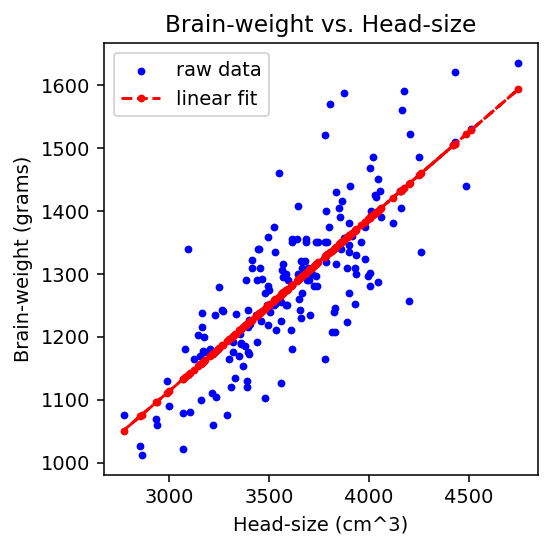

In [27]:
#define plot size in inches (width, height) $ resolution(DPI)
fig=plt.figure(figsize=(4,4), dpi=140)
plt.scatter(X_train, y_train, c='blue', marker='.', label='raw data')
plt.plot(X_train,y_fit, linestyle='dashed',marker=".",color="red",label='linear fit')
plt.plot()
plt.xlabel('Head-size (cm^3)')
plt.ylabel('Brain-weight (grams)')
plt.title('Brain-weight vs. Head-size')
#Legend
plt.legend(loc='upper left')

plt.show

In the model, it shows how well the raw data is correlated within the line of best fit using linear regression.

## <u>Creating a Predictive Model

Based on the regression analysis and the coefficients returned by the fit, create a 
predictive model and display the model equation in a cell. 

In [28]:
head_size=X_test[23][0]
#We chose [23] for the 24th iteration because of indexing starting at 0 for position 1.
#y_pred = lr.predict(X_test) 
brain_weight=0.274*head_size + 289.282

print('The model predicts the brain weight will be: {}'.format(brain_weight))

The model predicts the brain weight will be: 1345.826


In [29]:
print('The actual value is {}'.format(y_test[23]))

The actual value is 1430


In [30]:
print('R2 score testing data: {0:.3f}'.format(linear.score(X_test, y_test)))

R2 score testing data: 0.612


## How did accurate is the model?

### The R2 score for the testing data is 0.612, which means this predictive model 61.2% accurate. Therefore, the predictive model doesn't represent the real dataset in an efficient manner.

In [31]:
head_size

3856